In [1]:
import subprocess
import sys
import json
import time
from pathlib import Path

NOTEBOOKS = ["RNN_no_dale.ipynb", "RNN_dale.ipynb"]
N_RUNS = 10 # run each code 10 times to check if the pattern is randomly generated or by rules

OUTPUT_DIR = Path("multi_run_results")
OUTPUT_DIR.mkdir(exist_ok=True)

Path('figures').mkdir(exist_ok=True)
Path('final_results').mkdir(exist_ok=True)

In [2]:
all_results = []
for notebook in NOTEBOOKS:
    notebook_name = Path(notebook).stem

    for run in range(N_RUNS):
        print(f"\nRunning {notebook_name} run {run+1}/{N_RUNS}")

        start_time = time.time()
        output_path = OUTPUT_DIR / f"{notebook_name}_run{run+1}.ipynb"

        cmd = [
            sys.executable,
            "-m",
            "jupyter",
            "nbconvert",
            "--to",
            "notebook",
            "--execute",
            notebook,
            "--output",
            str(output_path),
            "--ExecutePreprocessor.timeout=3600"
        ]
        # run the notebook
        result = subprocess.run(cmd, capture_output=True, text=True)
        elapsed = time.time() - start_time

        if result.returncode == 0:
            print(f"✓ Finished in {elapsed:.1f}s")
            # read results generated by the notebook
            with open("results.json", "r") as f:
                results = json.load(f)
            results["notebook"] = notebook_name
            results["run"] = run + 1
            result_path = OUTPUT_DIR / f"{notebook_name}_run{run+1}.json"
            with open(result_path, "w") as f:
                json.dump(results, f, indent=2)
            all_results.append(results)
        else:
            print("✗ Failed:")
            print(result.stderr)

with open(OUTPUT_DIR / "all_results.json", "w") as f:
    json.dump(all_results, f, indent=2) # final results file containing all the runs

import os
os.remove("results.json")


Running RNN_no_dale run 1/10
✓ Finished in 162.4s

Running RNN_no_dale run 2/10
✓ Finished in 159.7s

Running RNN_no_dale run 3/10
✓ Finished in 157.1s

Running RNN_no_dale run 4/10
✓ Finished in 159.6s

Running RNN_no_dale run 5/10
✓ Finished in 159.4s

Running RNN_no_dale run 6/10
✓ Finished in 156.3s

Running RNN_no_dale run 7/10
✓ Finished in 159.3s

Running RNN_no_dale run 8/10
✓ Finished in 157.6s

Running RNN_no_dale run 9/10
✓ Finished in 157.4s

Running RNN_no_dale run 10/10
✓ Finished in 159.9s

Running RNN_dale run 1/10
✓ Finished in 168.3s

Running RNN_dale run 2/10
✓ Finished in 168.8s

Running RNN_dale run 3/10
✓ Finished in 171.2s

Running RNN_dale run 4/10
✓ Finished in 171.8s

Running RNN_dale run 5/10
✓ Finished in 169.4s

Running RNN_dale run 6/10
✓ Finished in 167.8s

Running RNN_dale run 7/10
✓ Finished in 168.0s

Running RNN_dale run 8/10
✓ Finished in 170.2s

Running RNN_dale run 9/10
✓ Finished in 168.4s

Running RNN_dale run 10/10
✓ Finished in 169.3s


80 rows total (20 runs x 4 students each)


,notebook,run,student,signed_corr,activity_mse,accuracy,pca_overlap
0,RNN_no_dale,1,A,0.023755,0.503992,0.838,0.095048
1,RNN_no_dale,1,B,0.117720,0.080446,0.000,0.482863
2,RNN_no_dale,1,C,-0.023252,0.211037,0.870,0.073535
3,RNN_no_dale,1,D,0.487252,0.013854,0.736,0.759901
4,RNN_no_dale,2,A,0.003401,1.551120,0.844,0.087232
5,RNN_no_dale,2,B,0.087659,0.028328,0.000,0.765248
6,RNN_no_dale,2,C,0.013868,0.269132,0.856,0.077890
7,RNN_no_dale,2,D,0.595269,0.000323,0.000,0.850132


Full summary saved to summary.csv


,notebook,student,signed_mean,signed_std,mse_mean,mse_std,pca_mean,pca_std,acc_mean,acc_std
0,RNN_dale,A,0.419,0.023,32.084,55.873,0.200,0.082,0.727,0.122
1,RNN_dale,B,0.351,0.047,0.180,0.159,0.662,0.123,0.224,0.211
2,RNN_dale,C,0.378,0.021,0.542,0.256,0.117,0.045,0.849,0.013
3,RNN_dale,D,0.797,0.089,0.015,0.028,0.856,0.042,0.375,0.282
4,RNN_no_dale,A,0.003,0.024,1.909,1.929,0.090,0.036,0.827,0.037
5,RNN_no_dale,B,0.183,0.060,0.044,0.024,0.759,0.117,0.412,0.261
6,RNN_no_dale,C,-0.006,0.017,0.279,0.050,0.095,0.028,0.864,0.008
7,RNN_no_dale,D,0.565,0.053,0.004,0.007,0.869,0.044,0.312,0.368


Significance tests saved to Significance_tests.csv


,metric,student,u_stat,p_value,Significance
0,signed_corr,A,100.0,0.000183,***
1,signed_corr,B,99.0,0.000246,***
2,signed_corr,C,100.0,0.000183,***
3,signed_corr,D,100.0,0.000183,***
4,pca_overlap,A,93.0,0.001315,**
5,pca_overlap,B,26.0,0.075662,n.s.
6,pca_overlap,C,67.0,0.212294,n.s.
7,pca_overlap,D,36.0,0.307489,n.s.
8,accuracy,A,21.0,0.031146,*
9,accuracy,B,29.5,0.128977,n.s.


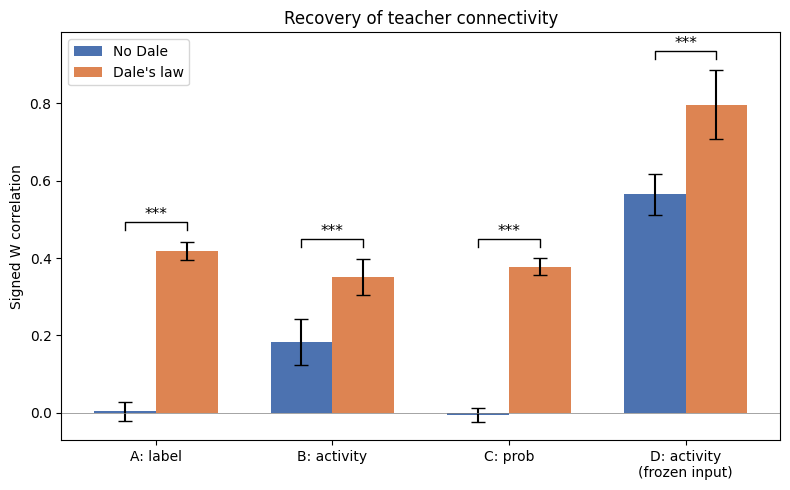

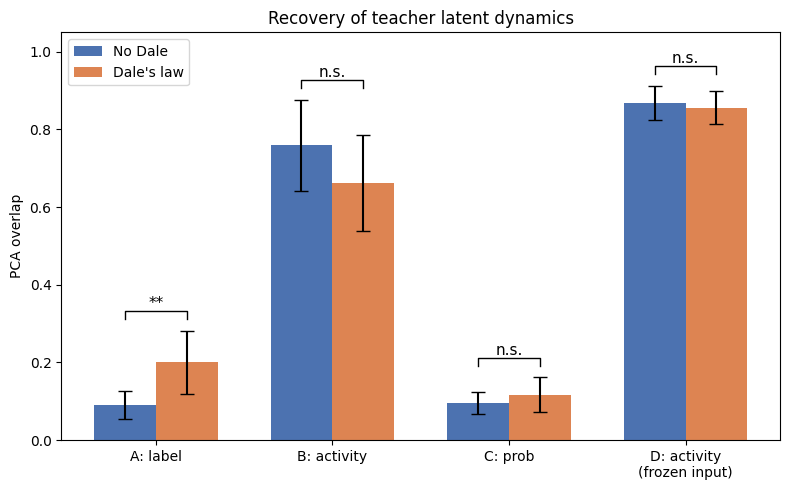

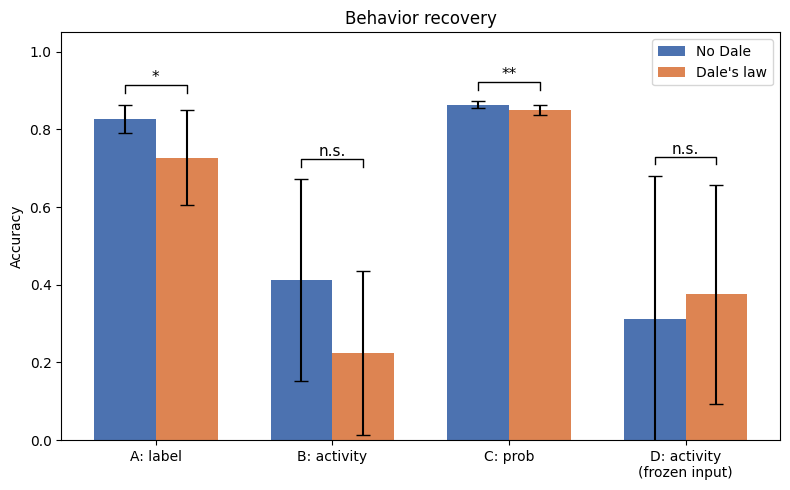

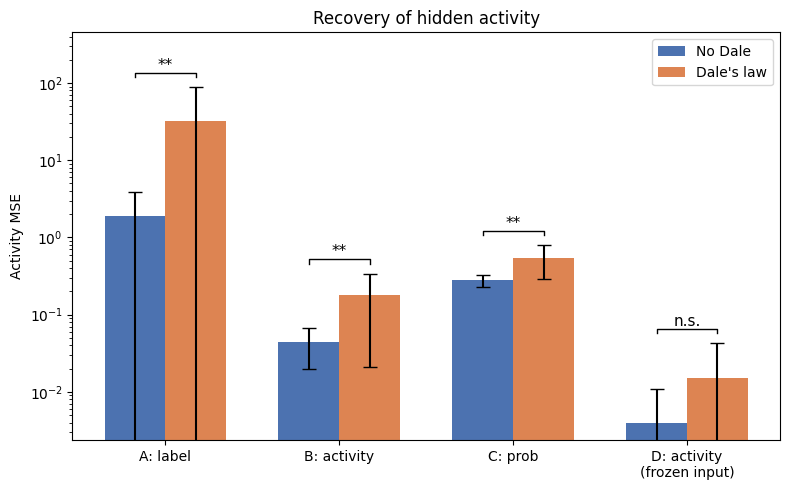

In [4]:
""" Results analysis """
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu # n = 5, therefore use non-parametric test

# Reshape results
students = ['A', 'B', 'C', 'D']
labels = [
    'A: label',
    'B: activity',
    'C: prob',
    'D: activity\n(frozen input)'
]
rows = [] # one student per row
for d in all_results: # all_results has 2 notebooks * 10 runs * 4 students
    for s in students:
        rows.append({
            'notebook': d['notebook'],
            'run': d['run'],
            'student': s,
            'signed_corr': d[f'{s}_signed_corr'],
            'activity_mse': d[f'{s}_activity_mse'],
            'accuracy': d[f'{s}_accuracy'],
            'pca_overlap': d[f'{s}_pca_overlap'],
        })
df = pd.DataFrame(rows)

print(f'{len(df)} rows total ({len(all_results)} runs x 4 students each)')
display(df.head(8))

# Summary table: calculate mean and std
summary = df.groupby(['notebook', 'student']).agg(
    signed_mean=('signed_corr', 'mean'),
    signed_std=('signed_corr', 'std'),
    mse_mean=('activity_mse', 'mean'),
    mse_std=('activity_mse', 'std'),
    pca_mean=('pca_overlap', 'mean'),
    pca_std=('pca_overlap', 'std'),
    acc_mean=('accuracy', 'mean'),
    acc_std=('accuracy', 'std'),
).round(3).reset_index()

summary.to_csv('final_results/summary.csv', index=False)
print('Full summary saved to summary.csv')
display(summary)

# Non-parametric test
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

test_rows = []
for metric in ['signed_corr', 'pca_overlap', 'accuracy', 'activity_mse']:
    for s in students:
        no_dale = df[(df.notebook == 'RNN_no_dale') & (df.student == s)][metric]
        dale = df[(df.notebook == 'RNN_dale') & (df.student == s)][metric]

        u_stat, p_val = mannwhitneyu(dale, no_dale, alternative='two-sided')
        test_rows.append({
            'metric': metric,
            'student': s,
            'u_stat': u_stat,
            'p_value': p_val,
            'Significance': p_to_stars(p_val),
        })
tests = pd.DataFrame(test_rows)
tests.to_csv('final_results/Significance_tests.csv', index=False)
print('Significance tests saved to Significance_tests.csv')
display(tests)

# plots
def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black', linewidth=1)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=11)

def plot_metric_comparison(metric_name, mean_col, std_col, ylabel, title, filename, ylim=None, log_y=False):
    means_nd = [summary[(summary.notebook == 'RNN_no_dale') & (summary.student == s)][mean_col].values[0] for s in students]
    stds_nd = [summary[(summary.notebook == 'RNN_no_dale') & (summary.student == s)][std_col].values[0] for s in students]

    means_d = [summary[(summary.notebook == 'RNN_dale') & (summary.student == s)][mean_col].values[0] for s in students]
    stds_d = [summary[(summary.notebook == 'RNN_dale') & (summary.student == s)][std_col].values[0] for s in students]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(students))
    w = 0.35
    ax.bar(x - w / 2, means_nd, w, yerr=stds_nd, capsize=5, label='No Dale', color='#4c72b0')
    ax.bar(x + w / 2, means_d, w, yerr=stds_d, capsize=5, label="Dale's law", color='#dd8452')

    metric_tests = tests[tests.metric == metric_name]
    for i, s in enumerate(students):
        sig = metric_tests[metric_tests.student == s].Significance.values[0]

        y = max(means_nd[i] + stds_nd[i], means_d[i] + stds_d[i])
        if log_y:
            bar_y = y * 1.35
            bar_h = y * 0.18
        else:
            bar_y = y + 0.03
            bar_h = 0.02
        add_sig_bar(ax, x[i] - w / 2, x[i] + w / 2, bar_y, bar_h, sig)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if log_y:
        ax.set_yscale('log')
        ax.set_ylim(top=ax.get_ylim()[1] * 2.0)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if metric_name == 'signed_corr':
        ax.axhline(0, color='gray', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'figures/{filename}', dpi=120, bbox_inches='tight')
    plt.show()

plot_metric_comparison(metric_name='signed_corr', mean_col='signed_mean', std_col='signed_std', ylabel=f'Signed W correlation', title='Recovery of teacher connectivity', filename='comparison_weight_recovery.png')
plot_metric_comparison(metric_name='pca_overlap', mean_col='pca_mean', std_col='pca_std', ylabel=f'PCA overlap', title='Recovery of teacher latent dynamics', filename='comparison_pca_overlap.png', ylim=(0, 1.05))
plot_metric_comparison(metric_name='accuracy', mean_col='acc_mean', std_col='acc_std', ylabel=f'Accuracy', title='Behavior recovery', filename='comparison_accuracy.png', ylim=(0, 1.05))
plot_metric_comparison(metric_name='activity_mse', mean_col='mse_mean', std_col='mse_std', ylabel=f'Activity MSE', title='Recovery of hidden activity', filename='comparison_activity_mse.png', log_y=True)